In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mlp-term-3-2025-kaggle-assignment-1/sample_submission.csv
/kaggle/input/mlp-term-3-2025-kaggle-assignment-1/train.csv
/kaggle/input/mlp-term-3-2025-kaggle-assignment-1/test.csv


# *DATA LOADING*

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


train = pd.read_csv('/kaggle/input/mlp-term-3-2025-kaggle-assignment-1/train.csv')
test = pd.read_csv('/kaggle/input/mlp-term-3-2025-kaggle-assignment-1/test.csv')

# print('Train shape:', train.shape)    Train shape: (10000, 9)
# print('Test shape:', test.shape)       Test shape: (3320, 8)

display(train.head())
display(test.head())

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,id,area_type,availability,location,size,total_sqft,bath,balcony,price
0,0,type_I,Ready To Move,Banashankari 2 nd Stage,3 BHK,1030.0,2.0,2.0,77.25
1,1,type_I,Ready To Move,Balagere,2 BHK,1210.0,2.0,1.0,83.00
2,2,type_I,17-Oct,Banashankari Stage V,3 BHK,1540.0,3.0,2.0,48.51
3,3,type_I,Ready To Move,Thigalarapalya,3 BHK,1830.0,4.0,2.0,135.00
4,4,type_III,Ready To Move,arudi,3 Bedroom,NaN,2.0,0.0,80.00


,id,area_type,availability,location,size,total_sqft,bath,balcony
0,0,type_II,Ready To Move,Banjara Layout,2 Bedroom,1050.0,2.0,1.0
1,1,type_I,Ready To Move,Rajiv Nagar,3 BHK,1690.0,3.0,1.0
2,2,type_II,Ready To Move,Hebbal,2 BHK,1100.0,2.0,1.0
3,3,type_III,Ready To Move,Munnekollal,6 Bedroom,1200.0,4.0,2.0
4,4,type_II,18-Apr,Choodasandra,4 Bedroom,2429.0,3.0,1.0


# *Identify data types of different columns*

In [3]:
print(train.dtypes)

id                int64
area_type        object
availability     object
location         object
size             object
total_sqft      float64
bath            float64
balcony         float64
price           float64
dtype: object


# *Present descriptive statistics of numerical columns*

In [4]:
# Numeric Columns
numeric_features = list(train.select_dtypes(include=["float64", "int64"]).columns)
# print(f"Numeric features: {numeric_features}")  ['id', 'total_sqft', 'bath', 'balcony', 'price']
if "id" in numeric_features:
    numeric_features.remove("id")
if "price" in numeric_features:
    numeric_features.remove("price")
print(f"Numeric features: {numeric_features}")


# Categorical Columns
categorical_features = list(train.select_dtypes(include=["object"]).columns)
print(f"Categorical features: {categorical_features}")

Numeric features: ['total_sqft', 'bath', 'balcony']
Categorical features: ['area_type', 'availability', 'location', 'size']


In [5]:
num_desc = train[numeric_features].describe().T
num_desc['median'] = train[numeric_features].median()
display(num_desc[['min', 'max', 'mean', 'median']])

,min,max,mean,median
total_sqft,1.0,52272.0,1570.095822,1279.0
bath,1.0,18.0,2.692029,2.0
balcony,0.0,3.0,1.585302,2.0


#### *Data overview: Dataset has numeric (total_sqft, bath, balcony, price) and categorical (area_type, availability, location, size) features. Target price is highly variable and right-skewed (as visible in the visualisations that follow).*


# *Identify and handle the missing values*
# *Identify and handle duplicates*
# *Identify and handle outliers*

# *Present at least three visualizations and provide insights for the same*

In [6]:
# Missing Values
missing = train.isnull().sum()
missing_percent = 100 * missing / len(train)
missing_info = pd.DataFrame({'MissingCount': missing, 'MissingPercent': missing_percent})
display(missing_info[missing_info['MissingCount'] > 0].sort_values('MissingCount', ascending=False))

,MissingCount,MissingPercent
balcony,475,4.75
bath,64,0.64
total_sqft,33,0.33
size,13,0.13
location,1,0.01


#### *Missing values: Only balcony, bath, total_sqft, size, and location had nulls. Filled numeric with median and categorical with mode to avoid biasing distributions.*

In [7]:
# For numeric columns: fill missing values with median
for col in ['balcony', 'bath', 'total_sqft']:
    median = train[col].median()
    train[col] = train[col].fillna(median)
    test[col] = test[col].fillna(median)

# For categorical: fill missing with mode
for col in ['size', 'location']:
    mode = train[col].mode()[0]
    train[col] = train[col].fillna(mode)
    test[col] = test[col].fillna(mode)

# print(missing)

In [8]:
# Duplicate Rows
dup_rows = train.duplicated(subset=train.columns.difference(['id']), keep=False)
num_dups = dup_rows.sum()
print(f"Number of duplicate rows : {num_dups}")

display(train[dup_rows].head())

Number of duplicate rows : 620


,id,area_type,availability,location,size,total_sqft,bath,balcony,price
8,8,type_I,Ready To Move,7th Phase JP Nagar,2 BHK,1035.0,2.0,1.0,39.33
12,12,type_I,Ready To Move,Sarjapur Road,4 BHK,4395.0,4.0,2.0,242.00
25,25,type_I,Ready To Move,7th Phase JP Nagar,3 BHK,1370.0,2.0,2.0,54.79
59,59,type_I,Ready To Move,Jalahalli,1 BHK,615.0,1.0,1.0,46.00
74,74,type_I,Ready To Move,Rajiv Nagar,4 BHK,2340.0,5.0,1.0,129.00


In [9]:
# Drop duplicates, keeping the first occurrence
train = train.drop_duplicates(subset=train.columns.difference(['id']), keep='first')
print('Duplicates dropped. New train shape:', train.shape)

Duplicates dropped. New train shape: (9638, 9)


#### *Duplicates: Detected duplicates excluding the unique id and dropped them to reduce leakage and overfitting.*

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


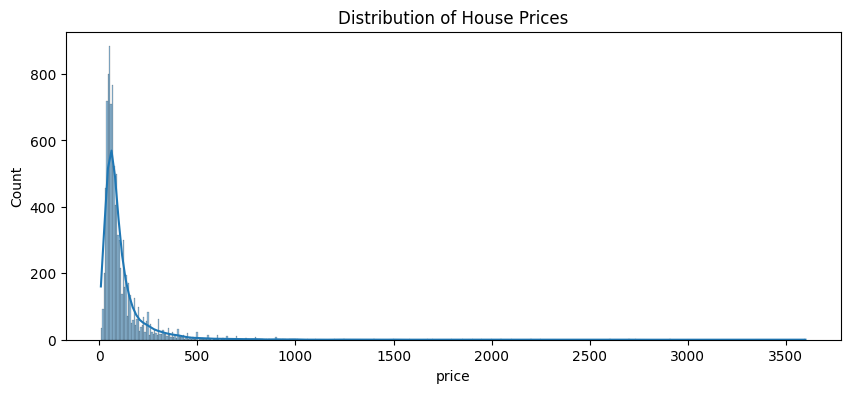

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


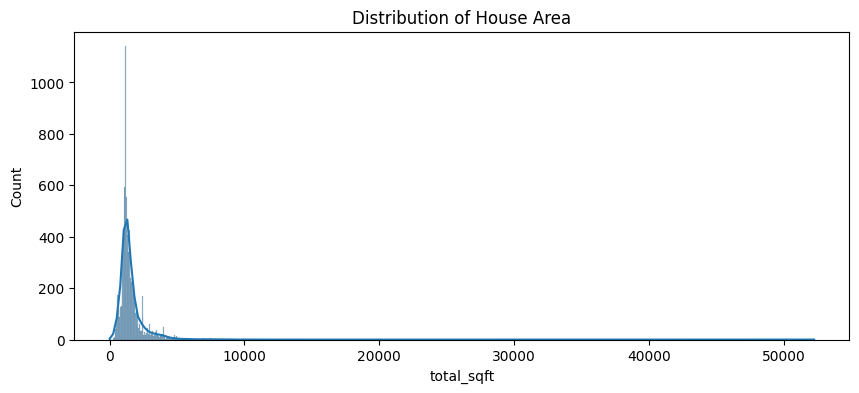

In [10]:
plt.figure(figsize=(10,4))
sns.histplot(train['price'], kde=True)
plt.title('Distribution of House Prices')
plt.show()

plt.figure(figsize=(10,4))
sns.histplot(train['total_sqft'], kde=True)
plt.title('Distribution of House Area')
plt.show()

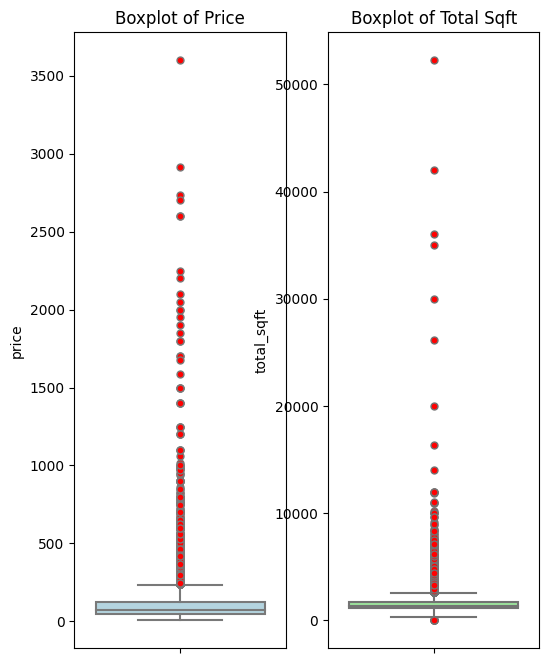

In [11]:
plt.figure(figsize=(6,8))
plt.subplot(1,2,1)
sns.boxplot(data=train, y='price', color='lightblue',flierprops=dict(marker='o', markerfacecolor='red', markersize=5))
plt.title('Boxplot of Price')

plt.subplot(1,2,2)
sns.boxplot(data=train, y='total_sqft', color='lightgreen',flierprops=dict(marker='o', markerfacecolor='red', markersize=5))
plt.title('Boxplot of Total Sqft')
plt.show()


In [12]:
train['price_log'] = np.log1p(train['price'])
train['total_sqft_log'] = np.log1p(train['total_sqft'])

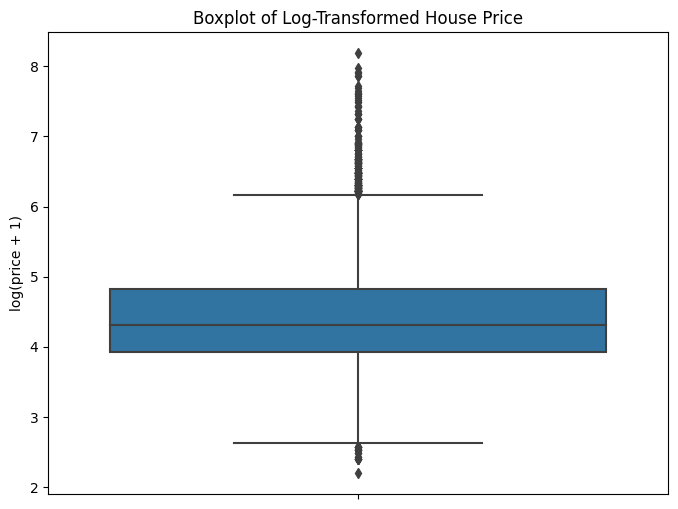

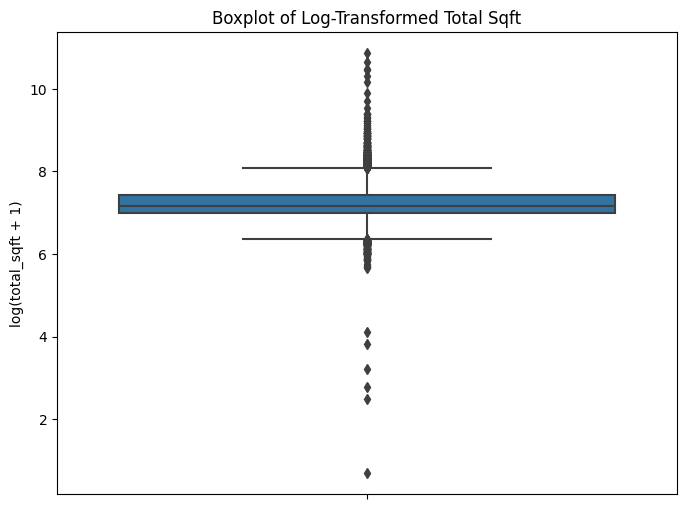

In [13]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=train['price_log'])
plt.title('Boxplot of Log-Transformed House Price')
plt.ylabel('log(price + 1)')
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(y=train['total_sqft_log'])
plt.title('Boxplot of Log-Transformed Total Sqft')
plt.ylabel('log(total_sqft + 1)')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


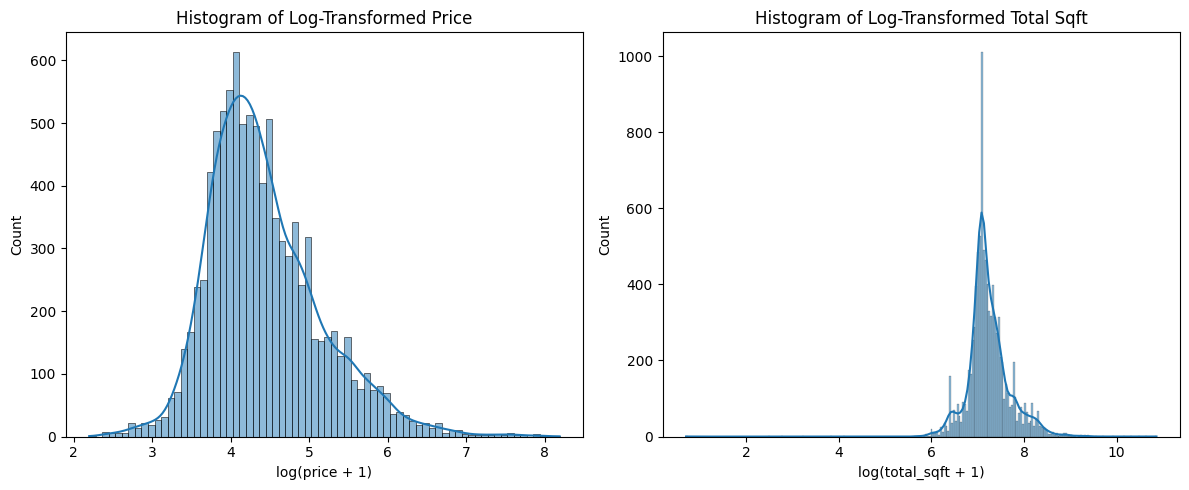

In [14]:
plt.figure(figsize=(12, 5))

# Histogram for log-transformed price
plt.subplot(1, 2, 1)
sns.histplot(train['price_log'], kde=True)
plt.title('Histogram of Log-Transformed Price')
plt.xlabel('log(price + 1)')

# Histogram for log-transformed total_sqft
plt.subplot(1, 2, 2)
sns.histplot(train['total_sqft_log'],  kde=True)
plt.title('Histogram of Log-Transformed Total Sqft')
plt.xlabel('log(total_sqft + 1)')

plt.tight_layout()
plt.show()

#### *Distributions: Histograms showed price and total_sqft are right-skewed; boxplots indicated many high-end outliers. After log-transform, both variables became more symmetric and compact.*

#### *Outliers handling: Chose log1p transformation over hard trimming/capping to preserve data while reducing the influence of extreme values.*

# *Scale Numerical features and Encode Categorical features*

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [16]:
feature_cols = ['area_type', 'availability', 'location', 'size', 'total_sqft', 'bath', 'balcony']
X = train[feature_cols].copy()
y = train['price_log'].copy()

numeric_features = ['total_sqft', 'bath', 'balcony']
categorical_features = ['area_type', 'availability', 'location', 'size']

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numeric_features),
        ('cat', categorical_pipeline, categorical_features)
    ]
)

#### *Feature scaling: Applied StandardScaler to numeric features inside a pipeline. This is essential for distance/kernel models (KNN, SVR, MLP) and harmless for tree-based models.*

#### *Categorical encoding: Used OneHotEncoder(handle_unknown='ignore') to safely handle unseen categories in test data without errors.*

In [17]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold

# *Model Building (at least 7)*

In [18]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_rmse(pipe, X, y, cv):
    scores = -cross_val_score(pipe, X, y, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=-1)
    return scores.mean(), scores.std()

In [19]:
from sklearn.linear_model import LinearRegression, Lasso, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor 
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor

In [20]:
cv = KFold(n_splits=3, shuffle=True, random_state=42)

models = {
    'Linear': LinearRegression(),
    'KNN': KNeighborsRegressor(n_neighbors=7, weights='distance'), 
    'SGDRegressor': SGDRegressor(loss='squared_error', penalty='l2', alpha=0.0001, max_iter=2000, random_state=42),
    'Tree': DecisionTreeRegressor(max_depth=8, random_state=42),
    'SVR_RBF': SVR(kernel='rbf', C=3.0, gamma='scale', epsilon=0.1),
    'RandomForest': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42),
    'MLPRegressor': MLPRegressor(hidden_layer_sizes=(100,), activation='relu', solver='adam', max_iter=500, random_state=42)
}

results = []
for name, model in models.items():
    pipe = Pipeline(steps=[('preprocess', preprocess), ('model', model)])
    mean_rmse, std_rmse = cv_rmse(pipe, X, y, cv)
    results.append({'Model': name, 'CV_RMSE_Mean': mean_rmse, 'CV_RMSE_STD': std_rmse})

results_df = pd.DataFrame(results).sort_values('CV_RMSE_Mean').reset_index(drop=True)
display(results_df)


,Model,CV_RMSE_Mean,CV_RMSE_STD
0,SVR_RBF,0.310116,0.005964
1,RandomForest,0.343587,0.008380
2,GradientBoosting,0.350378,0.004746
3,MLPRegressor,0.356658,0.005851
4,KNN,0.361469,0.004397
5,Tree,0.380982,0.009522
6,Linear,0.413262,0.037224
7,SGDRegressor,0.485532,0.043359


#### *Validation: Used KFold CV with RMSE on the log target for fair, repeatable comparisons across models.*



# *Hyperparameter Tuning on any 3 of the models*

In [21]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, uniform

svr_pipe = Pipeline([('preprocess', preprocess), ('model', SVR(kernel='rbf'))])

svr_params = {
    'model__C': loguniform(0.5, 50),         # focused around 1–50
    'model__gamma': loguniform(1e-3, 0.2),   # avoid ultra-large gamma
    'model__epsilon': uniform(0.03, 0.15)    # 0.03–0.18
}

svr_search = RandomizedSearchCV(
    svr_pipe, svr_params, n_iter=20, scoring='neg_root_mean_squared_error',
    cv=3, random_state=42, n_jobs=-1, verbose=1
)
svr_search.fit(X, y)
print('SVR best RMSE:', -svr_search.best_score_)
print('SVR best params:', svr_search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
SVR best RMSE: 0.3047044466893463
SVR best params: {'model__C': 2.8057582076672514, 'model__epsilon': 0.1726071459614874, 'model__gamma': 0.0483437145318464}


In [22]:
from sklearn.model_selection import GridSearchCV

rf_pipe = Pipeline([('preprocess', preprocess),
                    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))])

rf_params = {
    'model__n_estimators': [300, 500],
    'model__max_depth': [None, 20],
    'model__max_features': ['sqrt', 0.5],
    'model__min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    rf_pipe, rf_params, scoring='neg_root_mean_squared_error',
    cv=3, n_jobs=-1, verbose=1
)
rf_grid.fit(X, y)
print('RF best RMSE:', -rf_grid.best_score_)
print('RF best params:', rf_grid.best_params_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
RF best RMSE: 0.32655077008438627
RF best params: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 500}


In [23]:
gbr_pipe = Pipeline([('preprocess', preprocess),
                     ('model', GradientBoostingRegressor(random_state=42))])

gbr_params = {
    'model__n_estimators': [300, 500],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [2, 3],
    'model__subsample': [0.9, 1.0]
}

gbr_grid = GridSearchCV(
    gbr_pipe, gbr_params, scoring='neg_root_mean_squared_error',
    cv=3, n_jobs=-1, verbose=1
)
gbr_grid.fit(X, y)
print('GBR best RMSE:', -gbr_grid.best_score_)
print('GBR best params:', gbr_grid.best_params_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
GBR best RMSE: 0.32372976265148307
GBR best params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 500, 'model__subsample': 0.9}


# *Comparison of model performances*

In [24]:
tuned_searches = [
    ('SVR_RBF (tuned)', svr_search),
    ('RandomForest (tuned)', rf_grid),
    ('GradientBoosting (tuned)', gbr_grid),
]


tuned_results = []
for name, search in tuned_searches:
    tuned_results.append({
        'Model': name,
        'CV_RMSE_Mean': -search.best_score_, 
    })

tuned_results_df = pd.DataFrame(tuned_results)
display(tuned_results_df)

,Model,CV_RMSE_Mean
0,SVR_RBF (tuned),0.304704
1,RandomForest (tuned),0.326551
2,GradientBoosting (tuned),0.323730


In [25]:
results_df['Type'] = 'Baseline'
tuned_results_df['Type'] = 'Tuned'

compare_df = pd.concat([results_df, tuned_results_df], ignore_index=True)

compare_df = compare_df.sort_values('CV_RMSE_Mean').reset_index(drop=True)
display(compare_df)

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Model,CV_RMSE_Mean,CV_RMSE_STD,Type
0,SVR_RBF (tuned),0.304704,NaN,Tuned
1,SVR_RBF,0.310116,0.005964,Baseline
2,GradientBoosting (tuned),0.323730,NaN,Tuned
3,RandomForest (tuned),0.326551,NaN,Tuned
4,RandomForest,0.343587,0.008380,Baseline
5,GradientBoosting,0.350378,0.004746,Baseline
6,MLPRegressor,0.356658,0.005851,Baseline
7,KNN,0.361469,0.004397,Baseline
8,Tree,0.380982,0.009522,Baseline
9,Linear,0.413262,0.037224,Baseline


#### *Model comparison: Baseline models established a reference; tuned SVR/RandomForest/GradientBoosting improved RMSE further (Hyperparameter tuning step).*

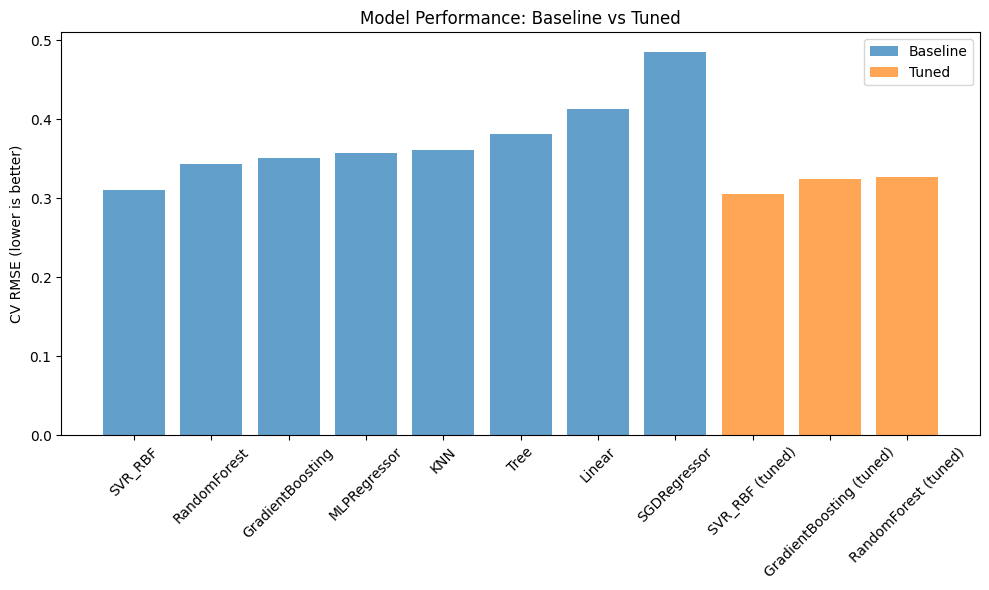

In [26]:
plt.figure(figsize=(10,6))
for t in ['Baseline', 'Tuned']:
    subset = compare_df[compare_df['Type'] == t]
    plt.bar(subset['Model'], subset['CV_RMSE_Mean'], label=t, alpha=0.7)

plt.ylabel('CV RMSE (lower is better)')
plt.xticks(rotation=45)
plt.title('Model Performance: Baseline vs Tuned')
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
# from sklearn.pipeline import Pipeline
# from sklearn.svm import SVR

# Ensure target exists
if 'log_price' not in train.columns:
    train['log_price'] = np.log1p(train['price'])

X_full = train[feature_cols].copy()
y_full = train['log_price'].copy()
X_test = test[feature_cols].copy()

# Use your latest best params from the fast search
final_model = Pipeline([
    ('preprocess', preprocess),
    ('model', SVR(kernel='rbf',
                  C=2.8057582076672514,
                  gamma=0.0483437145318464,
                  epsilon=0.1726071459614874))
])

final_model.fit(X_full, y_full)

log_preds = final_model.predict(X_test)
pred_price = np.expm1(log_preds)

submission = pd.DataFrame({'id': test['id'], 'price': pred_price})
submission.to_csv('submission.csv', index=False)
print('submission.csv saved:', submission.shape)
display(submission.head())

submission.csv saved: (3320, 2)


,id,price
0,0,64.491784
1,1,113.483130
2,2,62.189476
3,3,145.659853
4,4,212.836758


#### *Final model: Chose tuned RBF-SVR; trained on full data, predicted in log-space, and inverted with expm1 for submission.*